# Sea Level Pressure (SLP) Feature Tracking and associated Precipitation using  Scikit

---

## Overview

Within this notebook, we will cover:

1. How to filter continuous SLP data do identify features of interest.

2. How to use scikit-image’s `label()` function to identify coherent objects within the SLP field

3. How to overlay Precipitation and SLP minima locations for each time steps.

4. How to track identified ETCs through successive time steps.

## Prerequisites
| Concepts | Importance | Notes |
| --- | --- | --- |
| [xarray](https://foundations.projectpythia.org/core/xarray/) | Necessary | |
| [matplotlib](https://foundations.projectpythia.org/core/matplotlib/matplotlib-basics/) | Necessary | |
| [scikit-image](https://scikit-image.org/) | Useful | Mostly the the label function|
| [Cartopy](https://foundations.projectpythia.org/core/cartopy/cartopy) | Useful | |
| [IPython](https://ipython.readthedocs.io/en/latest/interactive/plotting.html) | Useful | For inline animation|

- **Time to learn**: 45 minutes

## Import Packages

In [117]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from skimage.measure import label, regionprops
from scipy.ndimage import minimum_filter
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.ticker import MaxNLocator, FuncFormatter

## Let's go through the basic steps to identify SLP features

### Open the dataset using xarray

We have a small subset of hourly ERA5 Reanalysis dataset for Sea Level Pressure and Precipitation for 2022 November 1. The precipitation dataset is only available for Northern Hemisphere. 

In [118]:
ds_SLP = xr.open_dataset("data/SLP_ex.nc")
ds_precip = xr.open_dataset("data/precip_ex.nc")

We select for only Northern Hemisphere for Sea Level Pressure dataset as well to associate the SLP features with precipitation

In [119]:
da_SLP = ds_SLP.SLP
lat_name = da_SLP.dims[1]
lat_vals = da_SLP[lat_name]
da_SLP = da_SLP.where(lat_vals >= 0, drop=True)
da_precip = ds_precip.ETC_tp

We make use of a set of parameters for identifying the SLP feature objects and tracking overlaps through time. 

### Define relevant set of parameters

Three values control what counts as a feature and how features are linked through time. We set them once here so the rest of the notebook stays readable. 
1. `threshold` - ERA5 reports sea-level pressure in pascals, so this is 1005 hPa. Grid cells below this value are flagged as part of a low. Everything at or above it is background.
2. `min_area`- The smallest feature we keep, measured in grid cells. Below threshold blobs smaller than 20 cells are treated as noise and dropped. Since we haven't smoothed the field yet, this is what stops single-cell specks from being counted as a feature.
3. `min_overlap` - The matching rule for tracking. A feature at one timestep is identified with a feature at the next when they share at least 20% overlap. Below that level, they're treated as separate features. Lower values follow faster moving systems but risk false links and higher values require a feature to barely move between steps.

In [120]:
threshold = 100500
min_area = 20
min_overlap = 0.2  

### Get the latitude and longitude 2d meshgrid for plotting

To plot SLP and precipitation with contourf() or contour(), we first create 2D latitude–longitude grids.

We do this separately because the two datasets have different grid sizes:

`SLP` : 1° × 1°  
`Precipitation` : 0.25° × 0.25° (Only over northern Hemisphere)


In [121]:
lat_SLP = da_SLP[da_SLP.dims[1]].values
lon_SLP = da_SLP[da_SLP.dims[2]].values

lat_precip = da_precip[da_precip.dims[1]].values
lon_precip = da_precip[da_precip.dims[2]].values

So each variable needs its own plotting latitude-longitude grid 

In [122]:
lon2d_SLP, lat2d_SLP = np.meshgrid(lon_SLP, lat_SLP)
lon2d_precip, lat2d_precip = np.meshgrid(lon_precip, lat_precip)

## Select low SLP features less than a threshold using scikit-image label function

The `detect_features()` function identifies low-pressure objects in a single SLP field. First, it creates a mask of all grid points where SLP is less than or equal to the chosen threshold. These grid points are treated as candidate low-pressure regions. The function then uses connected-component labeling to group neighboring grid points into separate features. Because `connectivity=2` is used, grid cells that touch along edges or corners are considered connected. After the initial labeling, very small features are removed using the `min_area` limit, so noisy or insignificant patches are not included. Finally, the remaining features are labeled again to produce a clean label map, where `0` represents the background and each positive integer represents a separate low-pressure feature.


In [123]:
def detect_features(field, threshold=threshold, min_area= min_area):
    mask = field <= threshold   # low pressure: SLP less than threshold

    labels = label(mask, connectivity=2) 

    for lab in np.unique(labels)[1:]:
        if np.sum(labels == lab) < min_area:
            labels[labels == lab] = 0

    labels = label(labels > 0, connectivity=2)

    return labels

## Let's look at the labelled feature plotted for one time step

Let's take a look at the labelled feature at time = 0 which at 2022 November 1 00:00 UTC along with precipitation overlay.

In [124]:
t = 0
slp = da_SLP.isel(time=t).values
precip = da_precip.isel(time=t).values
precip_floor = 0.05
precip_plot = np.where(precip >= precip_floor, precip, np.nan)

We call the `detect_features()` function with the parameters set above

In [125]:
labels = detect_features(slp, threshold=threshold, min_area=min_area)

We define the scales for plotting here

In [126]:
slp_vmin = float(da_SLP.min())
slp_vmax = float(da_SLP.max())
slp_levels = np.linspace(slp_vmin, slp_vmax, 16)
slp_norm = mcolors.Normalize(slp_vmin, slp_vmax)


precip_vmax = float(da_precip.quantile(0.99))
precip_norm = mcolors.Normalize(precip_floor, precip_vmax)

precip_cmap = plt.get_cmap("gray").copy()
precip_cmap.set_bad(alpha=0)


:::{warning}
To prevent a visual seam near 0/360 longitude, we use cyclic longitude for SLP filled contour
:::

In [127]:
lat2d_SLP_cyc = None

def get_cyclic_slp(slp2d):
    slp_cyc, lon_cyc = add_cyclic_point(slp2d, coord=lon_SLP)
    lon2d_cyc, lat2d_cyc = np.meshgrid(lon_cyc, lat_SLP)
    return slp_cyc, lon2d_cyc, lat2d_cyc

slp_cyc, lon2d_SLP_cyc, lat2d_SLP_cyc = get_cyclic_slp(slp)

### Lets plot the figure with SLP features and precipitation overlayed

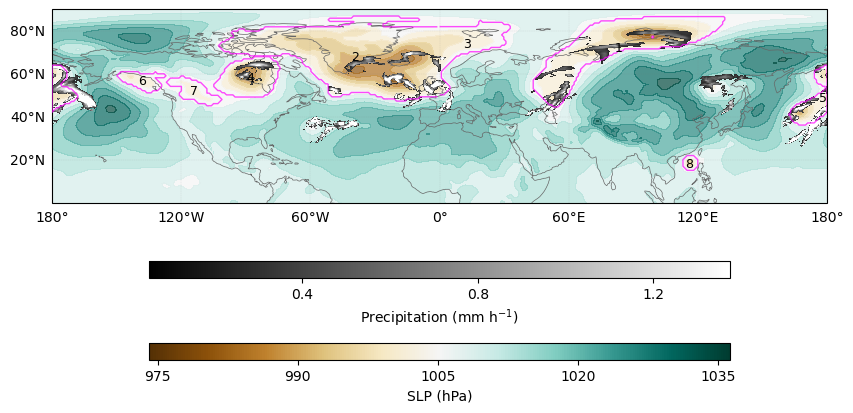

In [128]:
# ---- figure ----
fig, ax = plt.subplots(
    figsize=(10, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

fig.subplots_adjust(bottom=0.28)

cbar_slp = fig.colorbar(
    ScalarMappable(norm=slp_norm, cmap="BrBG"),
    ax=ax, orientation="horizontal",
    shrink=0.75, pad=0.08, aspect=35
)
cbar_slp.set_label("SLP (hPa)")
cbar_slp.locator = MaxNLocator(nbins=5)
cbar_slp.formatter = FuncFormatter(lambda x, pos: f"{x/100:.0f}")
cbar_slp.update_ticks()

cbar_precip = fig.colorbar(
    ScalarMappable(norm=precip_norm, cmap=precip_cmap),
    ax=ax, orientation="horizontal",
    shrink=0.75, pad=0.18, aspect=35
)
cbar_precip.set_label(r"Precipitation (mm h$^{-1}$)")
cbar_precip.locator = MaxNLocator(nbins=4)
cbar_precip.update_ticks()


# ---- SLP filled background ----
ax.contourf(
    lon2d_SLP_cyc,
    lat2d_SLP_cyc,
    slp_cyc,
    levels=slp_levels,
    cmap="BrBG",
    norm=slp_norm,
    extend="both",
    alpha = 0.7,
    transform=ccrs.PlateCarree(),
    zorder=1
)

    # ---- precipitation overlay ----
ax.pcolormesh(
    lon2d_precip,
    lat2d_precip,
    precip_plot,
    cmap=precip_cmap,
    norm=precip_norm,
    shading="auto",
    alpha=1,
    transform=ccrs.PlateCarree(),
    zorder=2
)



ax.contour(
    lon2d_SLP,
    lat2d_SLP,
    labels.astype(int),
    levels=[0.5],
    colors="fuchsia",
    linewidths=1,
    alpha=0.7,
    transform=ccrs.PlateCarree(),
    zorder=3
)

for r in regionprops(labels):
    y, x = r.centroid      # row, column
    iy = int(round(y))
    ix = int(round(x))

    ax.text(
        lon_SLP[ix],
        lat_SLP[iy],
        str(r.label),      # feature label, not track ID
        fontsize=9,
        color="black",
        ha="center",
        va="center",
        transform=ccrs.PlateCarree(),
        zorder=4
    )

ax.coastlines(color="0.4", linewidth=0.5)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.3,
    color="0.5",
    alpha=0.25,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

#ax.set_title(f"Detected SLP features with precipitation | time index = {t}")

plt.show()


This plot shows sea-level pressure (SLP) and precipitation for one time step. The SLP field is shown as a filled background using a `BrBG` brown to blue-green color scale, with lower pressure in brown and higher pressure in blue green. The magenta contours mark the detected low-pressure SLP features using the 1000 hPa threshold. Precipitation is overlaid in greyscale, with weaker precipitation shown in darker shades and stronger precipitation shown in lighter shades. Each detected feature is annotated with its `feature_ID`.

The main point of the plot is that some precipitation features are embedded within broad low-pressure SLP objects. This is visible over parts of North America and Europe, where precipitation appears within or near the detected SLP features. However, not all precipitation is captured by these SLP-defined objects. Some precipitation systems occur outside the detected low-pressure regions, especially in subtropical areas such as near Japan and over the Northern Hemisphere subtropical Atlantic.


:::{note}
It is also important to note that SLP varies strongly between maritime and inland regions because of topographic effects. Therefore, a fixed SLP threshold may identify features differently over land and ocean.
:::

### Lets add the SLP minimum for each identified feature

We identify candidate cyclone centers by applying a local minimum filter to the SLP field.
A grid point is tagged as a local minimum if its SLP value is equal to the minimum value within a surrounding 5 × 5 grid-cell window. Longitude is treated as cyclic, while latitude uses nearest-edge padding.m

In [145]:
def get_slp_minima(slp2d, lat, lon, size=5):
    minima = minimum_filter(
        slp2d,
        size=size,
        mode=("nearest", "wrap")
    )

    is_minima = slp2d == minima

    min_rows, min_cols = np.where(is_minima)

    min_lats = lat[min_rows]
    min_lons = lon[min_cols]
    min_slp = slp2d[min_rows, min_cols]

    return min_lats, min_lons, min_slp, min_rows, min_cols

In [146]:
min_lats, min_lons, min_slp, min_rows, min_cols = get_slp_minima(
    slp_cyc,
    lat_SLP,
    lon_SLP,
    size=5
)

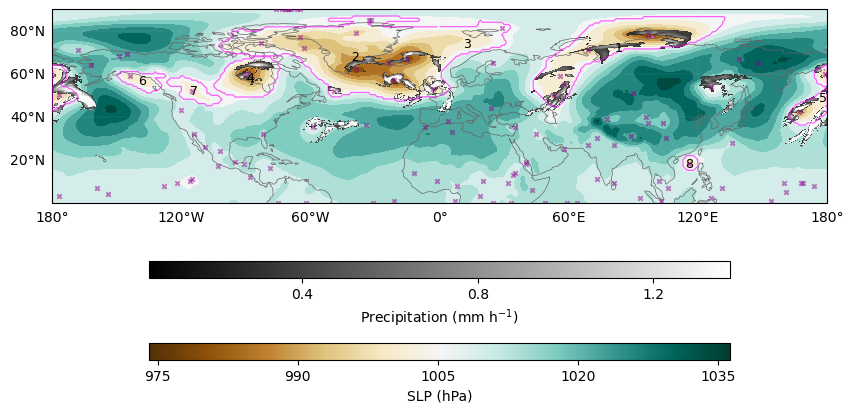

In [147]:
# ---- figure ----
fig, ax = plt.subplots(
    figsize=(10, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

fig.subplots_adjust(bottom=0.28)

cbar_slp = fig.colorbar(
    ScalarMappable(norm=slp_norm, cmap="BrBG"),
    ax=ax, orientation="horizontal",
    shrink=0.75, pad=0.08, aspect=35
)
cbar_slp.set_label("SLP (hPa)")
cbar_slp.locator = MaxNLocator(nbins=5)
cbar_slp.formatter = FuncFormatter(lambda x, pos: f"{x/100:.0f}")
cbar_slp.update_ticks()

cbar_precip = fig.colorbar(
    ScalarMappable(norm=precip_norm, cmap=precip_cmap),
    ax=ax, orientation="horizontal",
    shrink=0.75, pad=0.18, aspect=35
)
cbar_precip.set_label(r"Precipitation (mm h$^{-1}$)")
cbar_precip.locator = MaxNLocator(nbins=4)
cbar_precip.update_ticks()


# ---- SLP filled background ----
ax.contourf(
    lon2d_SLP_cyc,
    lat2d_SLP_cyc,
    slp_cyc,
    levels=slp_levels,
    cmap="BrBG",
    norm=slp_norm,
    extend="both",
    transform=ccrs.PlateCarree(),
    zorder=1
)

# ---- precipitation overlay ----
ax.pcolormesh(
    lon2d_precip,
    lat2d_precip,
    precip_plot,
    cmap=precip_cmap,
    norm=precip_norm,
    shading="auto",
    alpha=0.95,
    transform=ccrs.PlateCarree(),
    zorder=2
)



ax.contour(
    lon2d_SLP,
    lat2d_SLP,
    labels.astype(int),
    levels=[0.5],
    colors="fuchsia",
    linewidths=0.9,
    alpha=0.6,
    transform=ccrs.PlateCarree(),
    zorder=3
)

for r in regionprops(labels):
    y, x = r.centroid      # row, column
    iy = int(round(y))
    ix = int(round(x))

    ax.text(
        lon_SLP[ix],
        lat_SLP[iy],
        str(r.label),      # feature label, not track ID
        fontsize=9,
        color="black",
        ha="center",
        va="center",
        transform=ccrs.PlateCarree(),
        zorder=4
    )
ax.scatter(
    lon_SLP[min_cols],
    lat_SLP[min_rows],
    s=10,
    c="darkmagenta",
    marker="x",   # downward triangle
    alpha = 0.5,
    transform=ccrs.PlateCarree(),
    zorder=5
)

ax.coastlines(color="0.4", linewidth=0.5)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.3,
    color="0.9",
    alpha=0.25,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

#ax.set_title(f"Detected SLP features with precipitation | time index = {t}")

plt.show()


Now, we can see how the local minima are 

## Let's track SLP Features Over Time

We track the labelled SLP features from one time step to the next. Each detected feature is converted into a mask and compared with the masks from the previous time step. If a current feature overlaps strongly enough with a previous feature, it is treated as the same object and keeps the same track_id. If the overlap is too small, the feature is treated as a new object and is assigned a new track_id. For each time step, the code stores the feature ID, centroid location, and mask, which can later be used for plotting, animation, or further analysis of how the low-pressure systems move.

In [89]:
tracked = []
prev = {}
next_track_id = 1

for t in range(da_SLP.sizes["time"]):
    field = da_SLP.isel(time=t).values
    labels = detect_features(field, threshold=threshold, min_area=min_area)

    current = {}
    frame_info = []

    for r in regionprops(labels):
        mask = labels == r.label

        best_id = None
        best_overlap = 0.0

        for track_id, old_mask in prev.items():
            overlap = np.logical_and(mask, old_mask).sum() / mask.sum()
            if overlap > best_overlap:
                best_overlap = overlap
                best_id = track_id

        if best_overlap < min_overlap:
            best_id = next_track_id
            next_track_id += 1

        current[best_id] = mask
        frame_info.append({
            "track_id": best_id,
            "centroid_rc": r.centroid,   # row, col
            "mask": mask
        })

    tracked.append(frame_info)
    prev = current

## Let's look at the animation of the SLP features with precipitation overlayed

In [153]:


# ---- figure ----
fig, ax = plt.subplots(
    figsize=(10, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

fig.subplots_adjust(bottom=0.28)

cbar_slp = fig.colorbar(
    ScalarMappable(norm=slp_norm, cmap="BrBG"),
    ax=ax, orientation="horizontal",
    shrink=0.75, pad=0.08, aspect=35
)
cbar_slp.set_label("SLP (hPa)")
cbar_slp.locator = MaxNLocator(nbins=5)
cbar_slp.formatter = FuncFormatter(lambda x, pos: f"{x/100:.0f}")
cbar_slp.update_ticks()

cbar_precip = fig.colorbar(
    ScalarMappable(norm=precip_norm, cmap=precip_cmap),
    ax=ax, orientation="horizontal",
    shrink=0.75, pad=0.18, aspect=35
)
cbar_precip.set_label(r"Precipitation (mm h$^{-1}$)")
cbar_precip.locator = MaxNLocator(nbins=4)
cbar_precip.update_ticks()


def update(t):
    ax.clear()

    slp = da_SLP.isel(time=t).values
    precip = da_precip.isel(time=t).values
    precip_plot = np.where(precip >= precip_floor, precip, np.nan)
    lat_SLP = da_SLP[da_SLP.dims[1]].values
    lon_SLP = da_SLP[da_SLP.dims[2]].values

    slp_cyc, lon2d_SLP_cyc, lat2d_SLP_cyc = get_cyclic_slp(slp)
    min_lats, min_lons, min_slp, min_rows, min_cols = get_slp_minima(
        slp,
        lat_SLP,
        lon_SLP,
        size=5
    )
    
    ax.scatter(
        min_lons,
        min_lats,
        s=10,
        c="darkmagenta",
        marker="x",   # downward triangle
        alpha = 0.5,
        transform=ccrs.PlateCarree(),
        zorder=5
    )

    # ---- SLP filled background ----
    ax.contourf(
        lon2d_SLP_cyc,
        lat2d_SLP_cyc,
        slp_cyc,
        levels=slp_levels,
        cmap="BrBG",
        norm=slp_norm,
        extend="both",
        transform=ccrs.PlateCarree(),
        zorder=1
    )

    # ---- precipitation overlay ----
    ax.pcolormesh(
        lon2d_precip,
        lat2d_precip,
        precip_plot,
        cmap=precip_cmap,
        norm=precip_norm,
        shading="auto",
        alpha=0.95,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    # ---- tracked outlines and labels ----
    for feat in tracked[t]:
        mask = feat["mask"]

        ax.contour(
            lon2d_SLP,
            lat2d_SLP,
            mask.astype(int),
            levels=[0.5],
            colors="fuchsia",
            linewidths=0.9,
            alpha=0.6,
            transform=ccrs.PlateCarree(),
            zorder=3
        )

        y, x = feat["centroid_rc"]
        iy = int(round(y))
        ix = int(round(x))

        ax.text(
            lon_SLP[ix],
            lat_SLP[iy],
            str(feat["track_id"]),
            fontsize=9,
            color="black",
            ha="center",
            va="center",
            transform=ccrs.PlateCarree(),
            zorder=4
        )

    ax.coastlines(color="0.4", linewidth=0.5)

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.3,
        color="0.5",
        alpha=0.25,
        linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False

    #ax.set_title(f"Scikit tracked SLP features with Precipitation | time index = {t}")


anim = FuncAnimation(
    fig,
    update,
    frames=da_SLP.sizes["time"],
    interval=300,
    blit=False
)

plt.close(fig)
HTML(anim.to_jshtml())
#anim.save('my_animation.gif', writer='pillow', fps=30)


This animation shows the evolution of SLP and precipitation through time using the overlap tracking method. The numeric annotations help follow individual systems across successive times, including cases where the detected object appears as nested within the larger low SLP features. 

:::{warning}
1. The results may be sensitive to the chosen SLP threshold.
2. The workflow does not yet include smoothing or noise reduction.
3. Splits and merges between features are not explicitly flagged.
4. We do not yet extract detailed shape, size, intensity, or lifecycle statistics from each feature.
:::

## Summary
In this recipe, we identify low sea level pressure (SLP) features globally and track them through time. We use scikit-image.measure `label()` to detect coherent low-pressure objects. We track tracking identified features between time steps using spatial overlap percentage and made visualization for one time step and a hourly animation for duration of 1 day. We add precipitation and SLP minima location overlayed on these SLP feature tracks.

### What's next?
1. Adding smoothing or noise filtering before feature detection.
2. Comparing this contour-based method with scikit-image and scipy object-labeling approaches.
3. Extracting region properties such as area, centroid, perimeter, and intensity.
4. Testing sensitivity to different SLP thresholds.
5. Adding explicit split and merge detection during tracking.


## Resources and references